Examine change in aperiodic exponent in resting state periods before/following TBS sessions

### Preprocessing

In [1]:
import fooof
import pickle as pk
import copy

import mne
import numpy as np
import pandas as pd
import pylab as plt
import os
import sys
from glob import glob

sys.path.insert(0, '../lib/')  # add path to custom library

root = '../data/'

# Subjects with multiple iTBS sessions and more resting-state time
r01_subjects = ['S25_245', 'S23_214', 'S25_248', 'S25_247', 'S24_218', 'S23_211', 
              'S23_212', 'S24_219', 'S24_221', 'S24_222', 'S24_229', 'S24_237', 'S24_236', 'S24_220',]

# Subjects with only one iTBS session and less resting-state time (unused in manuscript)
k99_subjects = ['S25_255', 'S25_258', 'S25_120c', 'S26_263', 'S26_264']

In [11]:
from scipy.stats import zscore

def extract_resting_epochs(raw, start_samp, stop_samp, duration=2.0, buf=10):
    """
    Crops raw data between two samples and returns fixed-length epochs.
    """
    # 1. Convert samples to times (relative to raw start)
    t_min = start_samp / raw.info['sfreq']
    t_max = stop_samp / raw.info['sfreq']
    
    # 2. Create a copy and crop to the resting window
    # We use a copy to avoid altering the original 'full_eeg' object
    # Add a buffer to the initial time to reduce influence of previous stimulation events
    rest_raw = raw.copy().crop(tmin=t_min+buf, tmax=t_max-1)
    rest_raw.load_data()   
    rest_raw = rest_raw.filter(l_freq=0.3, h_freq=None, verbose=False)
    
    # 3. Slice into fixed-length segments
    epochs = mne.make_fixed_length_epochs(rest_raw, duration=duration, preload=True, reject_by_annotation=False)
    
    print(f"Created {len(epochs)} resting epochs of {duration}s each.")
    return epochs

def FOOOF_oscillation_detect(psds, freqs, band, peak_width_limits=[0.5, 12.0], 
                            max_n_peaks=4, min_peak_height=0.1, 
                            peak_threshold=3.0, aperiodic_mode='fixed'):
    
    from fooof import FOOOFGroup
    band_peaks = np.empty((psds.shape[1], psds.shape[0])).astype(float); band_peaks[:] = np.nan
    aperiodic_params = np.empty((psds.shape[1], psds.shape[0], 2)).astype(float); aperiodic_params[:] = np.nan

    # May want to parallelize this for loop
    for chan in np.arange(psds.shape[1]):
        
        # Initialize a FOOOFGroup object, specifying some parameters
        fg = FOOOFGroup(peak_width_limits=peak_width_limits, 
                        max_n_peaks=max_n_peaks, min_peak_height=min_peak_height,
                   peak_threshold=peak_threshold, aperiodic_mode=aperiodic_mode)
        
        # Fit FOOOF model across the matrix of power spectra
        fg.fit(freqs, psds[:, chan, :])
        
        # Extract peak parameters in theta range -- the modules built-in functions don't seem to work for this =( 
        for idx, f in enumerate(fg.group_results):

            aperiodic_params[chan, idx, 0] = f.aperiodic_params[0]
            aperiodic_params[chan, idx, 1] = f.aperiodic_params[1]
            
            if f[1].shape[0]==0:
                continue
            else:
                if band=='HFA':
                    det = (f[1][:, 0]>70) & (f[1][:, 0]<=99)
                elif band=='gamma':
                    det = (f[1][:, 0]>=30) & (f[1][:, 0]<=55) 
                elif band=='beta':
                    det = (f[1][:, 0]>13) & (f[1][:, 0]<=25)
                elif band=='alpha':
                    det = (f[1][:, 0]>8) & (f[1][:, 0]<=13)
                elif band=='theta':
                    det = f[1][:, 0]<=8
                else:
                    raise ValueError
                band_peaks[chan, idx] = np.sum(det)
        band_peaks[band_peaks==0] = np.nan
    
    return band_peaks, fg, aperiodic_params

def reject_outlier_epochs(epochs, count_cutoff=7, outlier_threshold=5):

    # Find outlier epochs
    eeg = epochs.get_data()
    bad_epochs = [np.unique(np.where(np.abs(zscore(eeg[:, cidx, :], axis=None))>outlier_threshold)[0]) for cidx in range(eeg.shape[1])]

    # Drop channels with too many bad epochs   
    channels = [s for s in epochs.ch_names]
    bad_epoch_count = [len(i) for i in bad_epochs]
    reject_channels = np.unique(list(np.array(channels)[np.array(bad_epoch_count)>count_cutoff]))
    reject_channels = list(reject_channels); reject_idx = [channels.index(i) for i in reject_channels]

    return bad_epochs, reject_channels

resting_state_blocks_r01 = [['BaselineLow', 'PreiTBS1High'], ['PreiTBS1Low', 'iTBS1'], 
                            ['PostiTBS1Low', 'PreShamiTBS1High'], ['PreShamiTBS1Low', 'PostShamiTBS1High'], 
                            ['PostShamiTBS1Low', 'PreiTBS2High'], ['PreiTBS2Low', 'iTBS2'], 
                            ['PostiTBS2Low', 'PreShamiTBS2High'], ['PreShamiTBS2Low', 'PostShamiTBS2High'], 
                            ['PostShamiTBS2Low', 'PreiTBS3High'], ['PreiTBS3Low', 'iTBS3'],
                            ['PostiTBS3Low', 'PreShamiTBS3High'], ['PreShamiTBS3Low', 'PostShamiTBS3High'], 
                            ['PostShamiTBS3Low', 'PreiTBS4High'], ['PreiTBS4Low', 'iTBS4']]

# Note that cTBS/iTBS experiment data is not used in this manuscript
resting_state_blocks_k99_iTBSfirst = [['Baseline', 'PreiTBS1'], ['PostiTBS1', 'PreShamiTBS1'],
                            ['PreShamiTBS1', 'PostShamiTBS1'], ['PostShamiTBS1', 'PrecTBS1'], 
                            ['PostcTBS1', 'DelayedPost']]

resting_state_blocks_k99_cTBSfirst = [['Baseline', 'PrecTBS1'], ['PostcTBS1', 'PreShamiTBS1'],
                            ['PreShamiTBS1', 'PostShamiTBS1'], ['PostShamiTBS1', 'PreiTBS1'], 
                            ['PostiTBS1', 'DelayedPost']]

# This subject had a unique structure that should be handled separately (unused in this manuscript)
resting_state_blocks_252 = [['BaselineLow', 'PrecTBS1High'], ['PrecTBS1Low', 'cTBS1'], 
                           ['PostcTBS1Low', 'PreShamiTBS1High'], ['PreShamiTBS1Low', 'PostShamiTBS1High'], 
                           ['PostShamiTBS1Low', 'PreiTBS1High'], ['PreiTBS1Low', 'iTBS1'], 
                           ['PostiTBS1Low', 'PreShamiTBS2High'], ['PreShamiTBS2Low', 'PostShamiTBS2High'],
                           ['PrecTBS2Low', 'cTBS2'], ['PostcTBS2Low', 'PreShamiTBS3High'], 
                           ['PreShamiTBS3Low', 'PostShamiTBS3High'], ['PreiTBS2Low', 'iTBS2'],
                           ['PostiTBS2Low', 'END']]

In [ ]:
import string

k99 = False
band = 'theta'
duration_ = 3.0
time_thresh = 30

for subject in r01_subjects:

    # Load full-session data
    fn_prefix = '../derivatives/pulse_labels/'+subject
    full_eeg = mne.io.read_raw_fif('../derivatives/pulse_labels/'+subject+'_unepoched_eeg.fif', preload=True, verbose=False)
    
    # Select desired stim target if multiple exist
    epochs_trigger = mne.read_epochs(fn_prefix+'_trigs-epo.fif', verbose=False)
    stim_targets = epochs_trigger.metadata['stim_target'].unique()
    
    ## May be necessary to specify targets for the K99 protocol
    if k99:
        target_choice = 0
        epochs_trigger = epochs_trigger[epochs_trigger.metadata['stim_target']==stim_targets[target_choice]]
    else:
        target_choice = 0
    
    aperiodic_dict = {}
    peaks_dict = {}
    power_dict = {}

    if k99:
        blockList = list(epochs_trigger.metadata['block'].unique())
        iTBS_index = blockList.index('iTBS1')
        cTBS_index = blockList.index('cTBS1')

        if iTBS_index<cTBS_index:
            rs_blocks = resting_state_blocks_k99_iTBSfirst
        else:
            rs_blocks = resting_state_blocks_k99_cTBSfirst
              
    for p in resting_state_blocks_r01[1:2]:
    
        # Identify resting-state data period
        block_pair = p
        block1 = block_pair[0]
        block2 = block_pair[1]

        if block2 == 'END':
            # Get metadata
            m_block1 = epochs_trigger.metadata[epochs_trigger.metadata['block']==block1]

            if len(m_block1)==0:
                aperiodic_dict[str(p)] = np.nan
                peaks_dict[str(p)] = np.nan
                continue

            # Get sample of last pulse in the first block
            s_block1_last = m_block1.iloc[-1]['sample'] 

            # This one is automatically the last sample
            s_block2_first = len(full_eeg)

        else:
            # Get metadata
            m_block1 = epochs_trigger.metadata[epochs_trigger.metadata['block']==block1]
            m_block2 = epochs_trigger.metadata[epochs_trigger.metadata['block']==block2]  # May need to adjust depending on whether there are Low/High blocks
    
            if ((len(m_block1)==0) or (len(m_block2)==0)):
                aperiodic_dict[str(p)] = np.nan
                peaks_dict[str(p)] = np.nan
                print('No samples for this block found! ' + block1 + ', '+block2)
                continue
            
            # Get sample of last pulse in the first block
            s_block1_last = m_block1.iloc[-1]['sample'] 
            
            # Now get sample from first pulse of the TBS block
            s_block2_first = m_block2.iloc[0]['sample']
        
        # Check that the time period is long enough (let's try at least 30 seconds)
        if ((s_block2_first-s_block1_last)/full_eeg.info['sfreq'])>time_thresh:
            pass
        else:
            print('Insufficient resting state time!')
            aperiodic_dict[str(p)] = np.nan
            peaks_dict[str(p)] = np.nan
            continue
        
        # Crop the EEG to the desired time and convert fixed-length epochs
        rest_epochs = extract_resting_epochs(full_eeg, s_block1_last, s_block2_first, duration=duration_)
        #rest_epochs.info['bads'] = epochs_trigger.info['bads']

        # Drop bad epochs (flat EEG) -- this may be too aggressive at times, so should keep an eye out
        # Some version of this is necessary as resting-state is when EEG file turnover occurs, causing flatline EEG
        rest_epochs.drop_bad(flat=dict(seeg=2e1))

        if len(rest_epochs)<int(time_thresh/duration_): #want at least 30 seconds of resting-state even after flatline exclusions
            rest_epochs = extract_resting_epochs(full_eeg, s_block1_last, s_block2_first, duration=duration_)
            
        # Extract power using same parameters as previously
        #method_ = 'welch'
        freq_range = (3, 180)

        method_ = 'multitaper'
        
        spec_rest = rest_epochs.pick(['seeg'], exclude=[]).compute_psd(method=method_, fmin=freq_range[0], fmax=freq_range[1], 
                                                 remove_dc=True, low_bias=True, adaptive=True,
                                                 tmin=0, tmax=duration_, 
                                                 )

        # Use an upper bound threshold or z-score threshold to get rid of noisy channels/epochs (same as in CCEP experiment)
        # Note this rejection is not yet integrated into the 30 second total data threshold
        bad_epochs, reject_channels = reject_outlier_epochs(rest_epochs, count_cutoff=len(rest_epochs)*0.25, outlier_threshold=5)
        
        # Run FOOOF oscillation detection
        psds = spec_rest.get_data()
        freqs = spec_rest.freqs
        band_peaks, fg, aperiodic_params = FOOOF_oscillation_detect(psds, freqs, band, aperiodic_mode='fixed')

        # Measure spectral power
        power_ = np.mean(np.log10(psds), axis=2)
        
        # Remove bad epochs
        assert len(bad_epochs) == power_.shape[1]
        for cidx in range(len(bad_epochs)):
            aperiodic_params[cidx, bad_epochs[cidx]] = np.nan
            band_peaks[cidx, bad_epochs[cidx]] = np.nan
            power_[bad_epochs[cidx], cidx] = np.nan

        # Throw away if less than 30 seconds worth of data
        #if np.any(aperiodic_params.shape[1]-np.isnan(aperiodic_params[:, :, 0]).sum(axis=1)<int(time_thresh/duration_)):
        if np.any(power_.shape[0]-np.isnan(power_).sum(axis=0)<int(time_thresh/duration_)):
            print('Not enough resting-state time!')
            continue
    
        # Save results
        aperiodic_dict[str(p)] = aperiodic_params
        peaks_dict[str(p)] = band_peaks
        power_dict[str(p)] = power_

    # Need to get the subject ID code corresponding to a given target
    target_code = string.ascii_lowercase[target_choice]

    #pk.dump(spec_rest.ch_names, open('./outputs/fooof_extendedrange/'+subject+'_'+target_code+'_channels.pkl', 'wb'))    
    #pk.dump(aperiodic_dict, open('./outputs/fooof_extendedrange/'+subject+'_'+target_code+'_'+band+'_aperiodic_params.pkl', 'wb'))
    #pk.dump(peaks_dict, open('./outputs/fooof_extendedrange/'+subject+'_'+target_code+'_'+band+'_peaks_dict.pkl', 'wb'))
    #pk.dump(power_dict, open('./outputs/fooof_multitaper/'+subject+'_'+target_code+'_'+band+'_power_dict.pkl', 'wb'))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_parameter_longitudinally(aperiodic_dict, channel_idx, param_idx, 
                                             param_name="Parameter", window_size=5):
    """
    Plots a FOOOF aperiodic parameter longitudinally with clear block boundaries 
    and a smoothed rolling average overlaid on top of the raw data.
    
    Parameters:
    -----------
    aperiodic_dict : dict
        Dictionary of shape (channels, trials, parameters).
    channel_idx : int
        Index of the channel to plot.
    param_idx : int
        Index of the parameter to plot (0=Offset, 1=Exponent).
    param_name : str
        Name of the parameter for labeling.
    window_size : int
        Size of the rolling window for smoothing (in trials).
    """
    all_raw_data = []
    all_smooth_data = []
    x_ticks = []
    x_labels = []
    block_boundaries = [0]
    
    for key in aperiodic_dict.keys():
        data_block = aperiodic_dict[key]
        
        if isinstance(data_block, float) and np.isnan(data_block):
            continue
            
        # Extract raw trial series for this block
        param_series = data_block[channel_idx, :, param_idx]
        n_trials = len(param_series)
        
        # Calculate rolling average exclusively within this block boundaries
        # min_periods=1 ensures it still plots points at the very beginning of blocks
        smooth_series = pd.Series(param_series).rolling(window=window_size, center=True, min_periods=1).mean().values
        
        # Append raw data and its matching NaN spacer
        all_raw_data.extend(param_series)
        all_raw_data.append(np.nan)
        
        # Append smooth data and its matching NaN spacer
        all_smooth_data.extend(smooth_series)
        all_smooth_data.append(np.nan)
        
        # Handle X-axis labeling math
        current_start = block_boundaries[-1]
        block_center = current_start + (n_trials / 2)
        x_ticks.append(block_center)
        x_labels.append(key)
        
        block_boundaries.append(current_start + n_trials + 1)

    all_raw_data = np.array(all_raw_data)
    all_smooth_data = np.array(all_smooth_data)
    x_indices = np.arange(len(all_raw_data))
    
    plt.figure(figsize=(16, 6))
    
    # 1. Background shading and partition boundaries
    for i in range(len(block_boundaries) - 1):
        start_x = block_boundaries[i]
        end_x = block_boundaries[i+1] - 1
        
        facecolor = '#f9f9f9' if i % 2 == 0 else '#ffffff'
        plt.axvspan(start_x - 0.5, end_x - 0.5, facecolor=facecolor, zorder=1)
        
        if i > 0:
            plt.axvline(x=start_x - 0.5, color='#e0e0e0', linestyle='--', linewidth=1.5, zorder=2)
            
    # 2. Plot Raw Data (Lightened up to let the trendline stand out)
    plt.plot(x_indices, all_raw_data, marker='o', markersize=3.5, linestyle='-', 
             linewidth=1.0, color='#1f77b4', alpha=0.4, label='Raw Trials', zorder=3)
    
    # 3. Plot Smoothed Trend Line (High contrast, slightly thicker)
    plt.plot(x_indices, all_smooth_data, linestyle='-', linewidth=2.5, 
             color='k', label=f'Rolling Mean (w={window_size})', zorder=4)
    
    # Aesthetics
    plt.xticks(x_ticks, x_labels, rotation=45, ha='right', fontsize=10)
    plt.xlim(-0.5, len(all_raw_data) - 0.5)
    plt.xlabel('Resting State Block / Key Sequence', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel(f'{param_name} Value', fontsize=12, fontweight='bold')
    plt.title(f'Longitudinal Evolution of {param_name} with Trendline (Channel {channel_idx})', fontsize=14, fontweight='bold', pad=15)
    
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', shadow=True)
    plt.grid(axis='y', linestyle=':', alpha=0.6, zorder=2)
    plt.tight_layout()
    plt.show()

## Population-level analysis

**Load preprocessed data from the CCEP experiment to identify the in-network channels**

In [2]:
import string

# Load dataframe of population-level results from the CCEP experiment
df_joint = pd.read_pickle('../outputs/iTBS_multitaper_HFA_onlyHigh_0.2dur_0.05step_outliersExcluded.pkl')

# Identify unique Subject-Target pairs
# We sort them to ensure suffix assignment is consistent (e.g., Target A is always 'a')
pairs = df_joint[['subject', 'target']].drop_duplicates().sort_values(['subject', 'target'])

# Create a suffix for subjects with multiple targets
# cumcount() gives 0 for the first target, 1 for the second, etc.
letters = list(string.ascii_lowercase)
pairs['suffix'] = pairs.groupby('subject').cumcount().map(lambda x: f"_{letters[x]}" if x < 26 else f"_{x}")

# Create the new unique subject ID
pairs['new_subject_id'] = pairs['subject'].astype(str) + pairs['suffix']

# Merge the new IDs back into the master DataFrame
df_joint = df_joint.merge(
    pairs[['subject', 'target', 'new_subject_id']], 
    on=['subject', 'target'], 
    how='left'
)

# Swap the old subject column for the new one and clean up
df_joint['original_subject'] = df_joint['subject'] # Keep a backup just in case
df_joint['subject'] = df_joint['new_subject_id']
df_joint.drop(columns=['new_subject_id'], inplace=True)

# Filter for desired electrodes in desired group of subjects with substantial resting-state data
bad_elec_keywords = 'out|lesion|damage|empty|unknown' 
r01_subject_strings = 'S25_245|S25_248|S25_247|S24_218|S23_211|S23_212|S24_219|S24_221|S24_222|S24_229|S24_237|S24_236|S24_220|S23_214'


plot_subset_top = df_joint[ 
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains(r01_subject_strings)) & 
                        (df_joint['is_bad'] == False) &
                        (df_joint['block']=='iTBS1') & 
                        (df_joint['is_lead'] == False) &
                        (df_joint['baseline_ptp']>10)
                            ]

**Identify "out-of-network" channels**

In [3]:
def get_smallest_channels(df, col_name, N=5):
    def get_n(sub):
        return N[sub] if isinstance(N, dict) else N
        
    return df.assign(abs_val=df[col_name].abs()).groupby('subject', group_keys=False).apply(
        lambda g: g.nsmallest(get_n(g.name), 'abs_val')
    ).drop(columns=['abs_val'])

plot_subset_bottom = df_joint[ 
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains(r01_subject_strings)) & 
                        (df_joint['is_bad'] == False) &
                        (df_joint['block']=='iTBS1') & 
                        (df_joint['is_lead'] == False) 
                            ]
sub_ns = {k: v for d in [{s: len(plot_subset_top[plot_subset_top['subject']==s])} for s in plot_subset_top['subject'].unique()] for k, v in d.items()}
plot_subset_bottom = get_smallest_channels(plot_subset_bottom[plot_subset_bottom['subject'].str.contains("|".join(map(str, sub_ns.keys())))], 'baseline_ptp', N=sub_ns)

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_48730/469109876.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.assign(abs_val=df[col_name].abs()).groupby('subject', group_keys=False).apply(


#### Helper plotting functions

In [5]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

def plot_group_oscillation_rate_longitudinally(plot_subset, subject_id, data_dir='./outputs/fooof/', window_size=10, band='theta'):
    """
    Extracts specified electrodes for a given subject, maps them to matrix row indices
    using case-insensitive matching, and plots their collective averaged oscillation rate.
    
    Parameters:
    -----------
    plot_subset : pd.DataFrame
        DataFrame containing target electrode configurations under the 'channel' field (all caps).
    subject_id : str
        The specific subject ID string to target (e.g., 'S25_245').
    data_dir : str
        Directory where pickle data bundles are stored.
    window_size : int
        Size of the rolling window (in trials) to smooth the population oscillation rate.
    """
    # 1. Grab desired channel names from the plot_subset DataFrame for this subject
    sub_df = plot_subset[plot_subset['subject'] == subject_id]
    if sub_df.empty:
        raise ValueError(f"No entries found for subject {subject_id} inside plot_subset.")
    
    # Ensure dataframe channel strings are stripped and forced to uppercase
    desired_channels = [str(ch).strip().upper() for ch in sub_df['channel'].unique()]
    
    # 2. Load the channel mapping list and peaks dictionary for the subject
    chan_file = os.path.join(data_dir, f"{subject_id}_channels.pkl")
    
    # Check for files matching the suffix patterns
    peaks_file = os.path.join(data_dir, f"{subject_id}_{band}_peaks_dict.pkl")
    if not os.path.exists(peaks_file):
        peaks_file = os.path.join(data_dir, f"{subject_id}_{band}_peaks.pkl")
    
    with open(chan_file, 'rb') as f:
        channel_mapping_list = pickle.load(f)
        
    with open(peaks_file, 'rb') as f:
        peaks_dict = pickle.load(f)
        
    # 3. Create a normalized version of the lookup list (all caps) to safely find indices
    normalized_mapping_list = [str(ch).strip().upper() for ch in channel_mapping_list]
        
    # 4. Resolve electrode names to matrix row indices
    matched_row_indices = []
    missing_channels = []
    for ch in desired_channels:
        if ch in normalized_mapping_list:
            matched_row_indices.append(normalized_mapping_list.index(ch))
        else:
            missing_channels.append(ch)
            
    if not matched_row_indices:
        raise ValueError(f"None of the target channels {desired_channels} were found in the channel mapping list for {subject_id} after string normalization.")
    if missing_channels:
        print(f"⚠️ Warning: {len(missing_channels)} electrodes could not be mapped to indices: {missing_channels}")
    else:
        print(f"✅ Successfully mapped {len(matched_row_indices)} electrodes for {subject_id}.")

    # 5. Longitudinal timeline assembly variables
    all_raw_avg = []
    all_smooth_rate = []
    x_ticks = []
    x_labels = []
    block_boundaries = [0]
    bold_boundary_flags = []
    
    # 6. Extract, binarize, group-average, and smooth data within blocks
    for key in peaks_dict.keys():
        data_block = peaks_dict[key]
        
        # Guard for insufficient resting state tracking blocks
        if isinstance(data_block, float) and np.isnan(data_block):
            continue
            
        # Select matrix slice for our specified electrodes: shape (len(matched_row_indices), trials)
        group_matrix = data_block[matched_row_indices, :]
        
        # Binarize: 1 if any peak exists, 0 otherwise
        binarized_matrix = np.where(np.nan_to_num(group_matrix) >= 1, 1, 0)
        
        # Take the average probability across our target electrodes slice for each trial (axis 0)
        group_trial_avg = np.mean(binarized_matrix, axis=0)
        n_trials = len(group_trial_avg)
        
        # Compute smooth trend curve on the combined group-averaged trial arrays
        smooth_rate = pd.Series(group_trial_avg).rolling(window=window_size, center=True, min_periods=1).mean().values
        
        # Stitch arrays adding NaN padding gaps for distinct section visualization
        all_raw_avg.extend(group_trial_avg)
        all_raw_avg.append(np.nan)
        all_smooth_rate.extend(smooth_rate)
        all_smooth_rate.append(np.nan)
        
        # Mathematical geometry setups for graph labeling offsets
        current_start = block_boundaries[-1]
        block_center = current_start + (n_trials / 2)
        x_ticks.append(block_center)
        x_labels.append(key)
        
        block_boundaries.append(current_start + n_trials + 1)
        
        # Check string lists cleanly to determine if an absolute iTBS boundary line is needed
        try:
            elements = ast.literal_eval(key)
            is_important = any(el in ['iTBS1', 'iTBS2', 'iTBS3'] for el in elements)
        except:
            is_important = False
        bold_boundary_flags.append(is_important)

    all_raw_avg = np.array(all_raw_avg)
    all_smooth_rate = np.array(all_smooth_rate)
    x_indices = np.arange(len(all_raw_avg))
    
    # 7. Plot generation
    plt.figure(figsize=(16, 5.5))
    
    # Alternating background shading fills & solid bold partition line injects
    for i in range(len(block_boundaries) - 1):
        start_x = block_boundaries[i]
        end_x = block_boundaries[i+1] - 1
        
        facecolor = '#f9f9f9' if i % 2 == 0 else '#ffffff'
        plt.axvspan(start_x - 0.5, end_x - 0.5, facecolor=facecolor, zorder=1)
        
        if i > 0:
            if bold_boundary_flags[i-1]:
                plt.axvline(x=start_x - 0.5, color='#111111', linestyle='-', linewidth=2.5, 
                            label='Post-iTBS Boundary' if i==1 or (i==2 and not bold_boundary_flags[0]) else "", zorder=2.5)
            else:
                plt.axvline(x=start_x - 0.5, color='#e0e0e0', linestyle='--', linewidth=1.5, zorder=2)
            
    # Plot raw point clouds (continuous density values between 0 and 1 since it's an average of channels)
    valid_mask = ~np.isnan(all_raw_avg)
    plt.scatter(x_indices[valid_mask], all_raw_avg[valid_mask], color='#1f77b4', 
                alpha=0.35, s=12, label='Averaged Raw Trials (across channels)', zorder=3)
    
    # Plot population rolling smoothed rate curve
    plt.plot(x_indices, all_smooth_rate, linestyle='-', linewidth=2.5, 
             color='#d62728', label=f'Group Oscillation Rate (w={window_size} trials)', zorder=4)
    
    # Aesthetics limits & text setups
    plt.xticks(x_ticks, x_labels, rotation=45, ha='right', fontsize=10)
    plt.xlim(-0.5, len(all_raw_avg) - 0.5)
    plt.ylim(-0.05, 1.05)
    
    plt.xlabel('Resting State Block / Key Sequence', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('Proportion Active / Oscillation Rate', fontsize=12, fontweight='bold')
    plt.title(f'Longitudinal {band} Oscillation Rate — Subject {subject_id} ({len(matched_row_indices)} Channels Combined)', 
              fontsize=14, fontweight='bold', pad=15)
    
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', shadow=True)
    plt.grid(axis='y', linestyle=':', alpha=0.6, zorder=2)
    plt.tight_layout()
    plt.show()

def plot_group_parameter_longitudinally(plot_subset, subject_id, param_idx, 
                                        param_name="Parameter", data_dir='./outputs/fooof/', window_size=10, band='theta',
                                       fname=None):
    """
    Extracts specified electrodes for a given subject, maps them to matrix row indices
    using case-insensitive matching, and plots the group-averaged continuous aperiodic 
    parameter longitudinally across blocks.
    
    Parameters:
    -----------
    plot_subset : pd.DataFrame
        DataFrame containing target electrode configurations under the 'channel' field (all caps).
    subject_id : str
        The specific subject ID string to target (e.g., 'S25_245').
    param_idx : int
        Index of the parameter to plot (0 for Offset, 1 for Exponent).
    param_name : str
        Name of the parameter for the y-axis label.
    data_dir : str
        Directory where pickle data bundles are stored.
    window_size : int
        Size of the rolling window (in trials) to smooth the population trend line.
    """
    # 1. Grab desired channel names from the plot_subset DataFrame for this subject
    sub_df = plot_subset[plot_subset['subject'] == subject_id]
    if sub_df.empty:
        raise ValueError(f"No entries found for subject {subject_id} inside plot_subset.")
    
    # Ensure dataframe channel strings are stripped and forced to uppercase
    desired_channels = [str(ch).strip().upper() for ch in sub_df['channel'].unique()]
    
    # 2. Load the channel mapping list and parameter dictionary for the subject
    chan_file = os.path.join(data_dir, f"{subject_id}_channels.pkl")
    
    # Check for files matching the suffix patterns
    params_file = os.path.join(data_dir, f"{subject_id}_{band}_aperiodic_params.pkl")
    if not os.path.exists(params_file):
        raise FileNotFoundError(f"Could not locate the aperiodic parameter file at: {params_file}")
    
    with open(chan_file, 'rb') as f:
        channel_mapping_list = pickle.load(f)
        
    with open(params_file, 'rb') as f:
        aperiodic_dict = pickle.load(f)
        
    # 3. Create a normalized version of the lookup list (all caps) to safely find indices
    normalized_mapping_list = [str(ch).strip().upper() for ch in channel_mapping_list]
        
    # 4. Resolve electrode names to matrix row indices
    matched_row_indices = []
    missing_channels = []
    for ch in desired_channels:
        if ch in normalized_mapping_list:
            matched_row_indices.append(normalized_mapping_list.index(ch))
        else:
            missing_channels.append(ch)
            
    if not matched_row_indices:
        raise ValueError(f"None of the target channels {desired_channels} were found in the channel mapping list for {subject_id} after string normalization.")
    if missing_channels:
        print(f"⚠️ Warning: {len(missing_channels)} electrodes could not be mapped to indices: {missing_channels}")
    else:
        print(f"✅ Successfully mapped {len(matched_row_indices)} electrodes for {subject_id}.")

    # 5. Longitudinal timeline assembly variables
    all_raw_avg = []
    all_smooth_avg = []
    x_ticks = []
    x_labels = []
    block_boundaries = [0]
    bold_boundary_flags = []
    
    # 6. Extract, group-average, and smooth data within blocks
    for key in aperiodic_dict.keys():
        data_block = aperiodic_dict[key]
        
        # Guard for insufficient resting state tracking blocks
        if isinstance(data_block, float) and np.isnan(data_block):
            continue
            
        # Select matrix slice for our specified electrodes and target parameter index
        # Shape of data_block is (channels, trials, parameters)
        # Sliced shape becomes (len(matched_row_indices), trials)
        group_matrix = data_block[matched_row_indices, :, param_idx]
        
        # Take the average parameter value across our target electrodes slice for each trial (axis 0)
        # Resulting shape becomes (trials,)
        group_trial_avg = np.nanmean(group_matrix, axis=0)
        n_trials = len(group_trial_avg)
        
        # Compute smooth trend curve on the combined group-averaged trial arrays
        smooth_avg = pd.Series(group_trial_avg).rolling(window=window_size, center=True, min_periods=1).mean().values
        
        # Stitch arrays adding NaN padding gaps for distinct section visualization
        all_raw_avg.extend(group_trial_avg)
        all_raw_avg.append(np.nan)
        all_smooth_avg.extend(smooth_avg)
        all_smooth_avg.append(np.nan)
        
        # Mathematical geometry setups for graph labeling offsets
        current_start = block_boundaries[-1]
        block_center = current_start + (n_trials / 2)
        x_ticks.append(block_center)
        x_labels.append(key)
        
        block_boundaries.append(current_start + n_trials + 1)
        
        # Check string lists cleanly to determine if an absolute iTBS boundary line is needed
        try:
            elements = ast.literal_eval(key)
            is_important = any(el in ['iTBS1', 'iTBS2', 'iTBS3'] for el in elements)
        except:
            is_important = False
        bold_boundary_flags.append(is_important)

    all_raw_avg = np.array(all_raw_avg)
    all_smooth_avg = np.array(all_smooth_rate) if 'all_smooth_rate' in locals() else np.array(all_smooth_avg)
    x_indices = np.arange(len(all_raw_avg))
    
    # 7. Plot generation
    plt.figure(figsize=(16, 5.5))
    
    # Alternating background shading fills & solid bold partition line injects
    for i in range(len(block_boundaries) - 1):
        start_x = block_boundaries[i]
        end_x = block_boundaries[i+1] - 1
        
        facecolor = '#f9f9f9' if i % 2 == 0 else '#ffffff'
        plt.axvspan(start_x - 0.5, end_x - 0.5, facecolor=facecolor, zorder=1)
        
        if i > 0:
            if bold_boundary_flags[i-1]:
                plt.axvline(x=start_x - 0.5, color='#111111', linestyle='-', linewidth=2.5, 
                            label='Post-iTBS Boundary' if i==1 or (i==2 and not bold_boundary_flags[0]) else "", zorder=2.5)
            else:
                plt.axvline(x=start_x - 0.5, color='#e0e0e0', linestyle='--', linewidth=1.5, zorder=2)
            
    # Plot raw continuous values using a line plot with reduced alpha opacity 
    # instead of a scatter so you can trace individual sample jumps easier
    plt.plot(x_indices, all_raw_avg, marker='o', markersize=3.5, linestyle='-', 
             linewidth=1.0, color='#1f77b4', alpha=0.4, label='Averaged Raw Trials (across channels)', zorder=3)
    
    # Plot population rolling smoothed rate curve
    plt.plot(x_indices, all_smooth_avg, linestyle='-', linewidth=2.5, 
             color='darkblue', label=f'Group Rolling Mean (w={window_size} trials)', zorder=4)
    
    # Aesthetics limits & text setups
    plt.xticks(x_ticks, x_labels, rotation=45, ha='right', fontsize=10)
    plt.xlim(-0.5, len(all_raw_avg) - 0.5)
    
    # Automatically bound y-limits to actual data ranges since parameters aren't strictly bounded between 0 and 1
    ymin = np.nanmin(all_raw_avg)
    ymax = np.nanmax(all_raw_avg)
    yrange = ymax - ymin
    plt.ylim(ymin - 0.05 * yrange, ymax + 0.05 * yrange)
    
    plt.xlabel('Resting State Block / Key Sequence', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel(f'Group Averaged {param_name}', fontsize=12, fontweight='bold')
    plt.title(f'Longitudinal Evolution of {param_name} — Subject {subject_id} ({len(matched_row_indices)} Channels Combined)', 
              fontsize=14, fontweight='bold', pad=15)
    
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', shadow=True)
    plt.grid(axis='y', linestyle=':', alpha=0.6, zorder=2)
    plt.tight_layout()

    if fname:
        plt.savefig(fname)
        
    plt.show()



In [6]:
import os
import pickle
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_group_block_distribution_zscored(plot_subset, param_idx, param_name="Parameter", data_dir='./outputs/fooof/', band='theta',
                                         ylim_=None):
    """
    Loops through all subjects in a DataFrame, extracts specified electrodes, 
    z-scores the data per-channel based on the first two baseline blocks, 
    averages across channels, and then averages across trials within each resting 
    state block. Plots the population distribution for each block.
    
    Parameters:
    -----------
    plot_subset : pd.DataFrame
        DataFrame containing target electrode configurations under the 'channel' and 'subject' fields.
    param_idx : int
        Index of the parameter to plot (0 for Offset, 1 for Exponent).
    param_name : str
        Name of the parameter for the y-axis label.
    data_dir : str
        Directory where pickle data bundles are stored.
        
    Returns:
    --------
    df_plot : pd.DataFrame
        The aggregated, z-scored block-level data used for plotting.
    """
    records = []
    subjects = plot_subset['subject'].unique()
    block_order = [] 
    
    # Define exact string representations of the baseline blocks to use for the z-score calculation
    baseline_keys = ["['BaselineLow', 'PreiTBS1High']", "['PreiTBS1Low', 'iTBS1']"]
    
    # 1. Loop through all subjects in the subset
    for subject_id in subjects:
        sub_df = plot_subset[plot_subset['subject'] == subject_id]
        desired_channels = [str(ch).strip().upper() for ch in sub_df['channel'].unique()]
        
        # Check for necessary files
        chan_file = os.path.join(data_dir, f"{subject_id}_channels.pkl")
        params_file = os.path.join(data_dir, f"{subject_id}_{band}_aperiodic_params.pkl")
        
        if not os.path.exists(chan_file) or not os.path.exists(params_file):
            print(f"⚠️ Skipping {subject_id}: Could not locate .pkl files.")
            continue
            
        with open(chan_file, 'rb') as f:
            channel_mapping_list = pickle.load(f)
        with open(params_file, 'rb') as f:
            aperiodic_dict = pickle.load(f)
            
        normalized_mapping_list = [str(ch).strip().upper() for ch in channel_mapping_list]
        
        # Map channel strings to indices
        matched_row_indices = [
            normalized_mapping_list.index(ch) 
            for ch in desired_channels 
            if ch in normalized_mapping_list
        ]
        
        if not matched_row_indices:
            print(f"⚠️ Skipping {subject_id}: None of the target channels mapped successfully.")
            continue
            
        # 2. Extract baseline data to compute per-channel Mean and Std
        baseline_data_list = []
        for b_key in baseline_keys:
            if b_key in aperiodic_dict:
                b_data = aperiodic_dict[b_key]
                if isinstance(b_data, np.ndarray):
                    # Slice matrix: (matched_channels, trials) for the specific parameter
                    baseline_data_list.append(b_data[matched_row_indices, :, param_idx])
                    
        if not baseline_data_list:
            print(f"⚠️ Skipping {subject_id}: No baseline blocks found for z-scoring.")
            continue
            
        # Concatenate baseline trials across axis 1 (trials) -> Shape: (matched_channels, total_baseline_trials)
        baseline_concat = np.concatenate(baseline_data_list, axis=1)
        
        # Calculate per-channel baseline mean and std, keeping dimensions for numpy broadcasting -> Shape: (matched_channels, 1)
        chan_baseline_mean = np.nanmean(baseline_concat, axis=1, keepdims=True)
        chan_baseline_std = np.nanstd(baseline_concat, axis=1, keepdims=True)
        
        # Prevent division by zero if a channel has exactly zero variance in the baseline
        chan_baseline_std[chan_baseline_std == 0] = np.nan
        
        print(f"✅ Successfully mapped {len(matched_row_indices)} electrodes and established baseline for {subject_id}.")
            
        # 3. Z-Score, Extract, and double-average data (across channels, then across trials)
        for key, data_block in aperiodic_dict.items():
            # Track chronological block sequence based on order of appearance
            if key not in block_order:
                block_order.append(key)
                
            # Guard for missing/insufficient resting state blocks
            if isinstance(data_block, float) and np.isnan(data_block):
                continue
                
            # Slice matrix: (channels, trials)
            group_matrix = data_block[matched_row_indices, :, param_idx]
            
            # --- APPLY Z-SCORING ---
            # Broadcasts baseline stats across all trials for each respective channel row
            z_scored_matrix = (group_matrix - chan_baseline_mean) / chan_baseline_std
            
            # Average across channels (axis 0) -> gives (trials,)
            group_trial_avg = np.nanmean(z_scored_matrix, axis=0)
            
            # Average across trials -> gives single scalar value for the block
            block_avg = np.nanmean(group_trial_avg)
            
            # Append to our tidy data list
            records.append({
                'Subject': subject_id,
                'Block': key,
                'Value': block_avg
            })
            
    if not records:
        raise ValueError("No valid data collected across any subjects to plot.")
        
    df_plot = pd.DataFrame(records)
    
    # 4. Plot Generation
    plt.figure(figsize=(16, 6.5))
    
    # Create the underlying boxplot to show distribution (quartiles/median)
    ax = sns.boxplot(data=df_plot, x='Block', y='Value', order=block_order, 
                     color='#f0f0f0', showfliers=False, width=0.6, zorder=1)
    
    # Overlay individual subject points to show the exact spread and missingness
    sns.stripplot(data=df_plot, x='Block', y='Value', order=block_order,
                  hue='Subject', palette='tab20', size=7, alpha=0.8, jitter=0.2, zorder=3)
    
    # Aesthetics: Alternating background shading & iTBS boundary lines 
    for i, key in enumerate(block_order):
        # Shading
        facecolor = '#f9f9f9' if i % 2 == 0 else '#ffffff'
        plt.axvspan(i - 0.5, i + 0.5, facecolor=facecolor, zorder=0)
        
        # iTBS Boundaries
        if i > 0:
            try:
                elements = ast.literal_eval(block_order[i-1])
                is_important = any(el in ['iTBS1', 'iTBS2', 'iTBS3'] for el in elements)
            except:
                is_important = False
                
            if is_important:
                plt.axvline(x=i - 0.5, color='#111111', linestyle='-', linewidth=2.5, zorder=2)
            else:
                plt.axvline(x=i - 0.5, color='#e0e0e0', linestyle='--', linewidth=1.5, zorder=2)

    # Formatting and labels
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.xlim(-0.5, len(block_order) - 0.5)
    if ylim_:
        plt.ylim(ylim_[0], ylim_[1])
    
    # Add a horizontal line at Y=0 to denote the baseline average
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, zorder=2, alpha=0.7, label='Baseline Mean (Z=0)')
    
    plt.xlabel('Resting State Block / Key Sequence', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel(f'Z-Scored {param_name}', fontsize=12, fontweight='bold')
    plt.title(f'Standardized Population Distribution of {param_name} Across Longitudinal Blocks', 
              fontsize=14, fontweight='bold', pad=15)
    
    # Place legend outside the plot
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True, 
               facecolor='white', shadow=True, title='Subject ID', title_fontsize='11')
    
    plt.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)
    plt.tight_layout()
    plt.show()
    
    return df_plot


def plot_block_distribution_population(plot_subset, param_idx, param_name="Parameter", data_dir='./outputs/fooof/', band='theta',
                                      ylim_=None, block_order=None, fname=None):
    """
    Loops through all subjects in a DataFrame, extracts specified electrodes, 
    z-scores the data per-channel based on the first two baseline blocks, 
    averages across channels, and then averages across trials within each resting 
    state block. Plots the population distribution and population mean for each block.
    
    Parameters:
    -----------
    plot_subset : pd.DataFrame
        DataFrame containing target electrode configurations under the 'channel' and 'subject' fields.
    param_idx : int
        Index of the parameter to plot (0 for Offset, 1 for Exponent).
    param_name : str
        Name of the parameter for the y-axis label.
    data_dir : str
        Directory where pickle data bundles are stored.
    band : str
        Frequency band string prefix used for file lookup.
    ylim_ : tuple, optional
        Y-axis limits for the plot (min, max).
    block_order : list of str, optional
        A specific ordering of keys for which to show the resulting data. 
        If None, the order is inferred dynamically from the data.
        
    Returns:
    --------
    df_plot : pd.DataFrame
        The aggregated, z-scored block-level data used for plotting.
    """
    records = []
    subjects = plot_subset['subject'].unique()
    
    # Check if we need to infer the block order or use the provided one
    infer_order = block_order is None
    if infer_order:
        block_order = [] 
    
    # Define exact string representations of the baseline blocks to use for the z-score calculation
    baseline_keys = ["['BaselineLow', 'PreiTBS1High']"]
    
    # 1. Loop through all subjects in the subset
    for subject_id in subjects:
        sub_df = plot_subset[plot_subset['subject'] == subject_id]
        desired_channels = [str(ch).strip().upper() for ch in sub_df['channel'].unique()]
        
        # Check for necessary files
        chan_file = os.path.join(data_dir, f"{subject_id}_channels.pkl")
        params_file = os.path.join(data_dir, f"{subject_id}_{band}_aperiodic_params.pkl")
        
        if not os.path.exists(chan_file) or not os.path.exists(params_file):
            print(f"⚠️ Skipping {subject_id}: Could not locate .pkl files.")
            continue
            
        with open(chan_file, 'rb') as f:
            channel_mapping_list = pickle.load(f)
        with open(params_file, 'rb') as f:
            aperiodic_dict = pickle.load(f)
            
        normalized_mapping_list = [str(ch).strip().upper() for ch in channel_mapping_list]
        
        # Map channel strings to indices
        matched_row_indices = [
            normalized_mapping_list.index(ch) 
            for ch in desired_channels 
            if ch in normalized_mapping_list
        ]
        
        if not matched_row_indices:
            print(f"⚠️ Skipping {subject_id}: None of the target channels mapped successfully.")
            continue
            
        # 2. Extract baseline data to compute per-channel Mean and Std
        baseline_data_list = []
        for b_key in baseline_keys:
            if b_key in aperiodic_dict:
                b_data = aperiodic_dict[b_key]
                if isinstance(b_data, np.ndarray):
                    baseline_data_list.append(b_data[matched_row_indices, :, param_idx])
                    
        if not baseline_data_list:
            print(f"⚠️ Skipping {subject_id}: No baseline blocks found for z-scoring.")
            continue
            
        baseline_concat = np.concatenate(baseline_data_list, axis=1)
        chan_baseline_mean = np.nanmean(baseline_concat, axis=1, keepdims=True)
        chan_baseline_std = np.nanstd(baseline_concat, axis=1, keepdims=True)
        chan_baseline_std[chan_baseline_std == 0] = np.nan
        
        print(f"✅ Successfully mapped {len(matched_row_indices)} electrodes and established baseline for {subject_id}.")
            
        # 3. Z-Score, Extract, and double-average data (across channels, then across trials)
        for key, data_block in aperiodic_dict.items():
            
            # If an order is provided and this key isn't in it, skip it to save processing time
            if not infer_order and key not in block_order:
                continue
                
            if infer_order and key not in block_order:
                block_order.append(key)
                
            if isinstance(data_block, float) and np.isnan(data_block):
                continue
                
            group_matrix = data_block[matched_row_indices, :, param_idx]
            z_scored_matrix = (group_matrix - chan_baseline_mean) / chan_baseline_std
            group_trial_avg = np.nanmean(z_scored_matrix, axis=0)
            block_avg = np.nanmean(group_trial_avg)
            
            records.append({
                'Subject': subject_id,
                'Block': key,
                'Value': block_avg
            })
            
    if not records:
        raise ValueError("No valid data collected across any subjects to plot.")
        
    df_plot = pd.DataFrame(records)
    
    # 4. Plot Generation
    plt.figure(figsize=(16, 6.5))
    
    # Create the underlying boxplot to show distribution (quartiles/median)
    ax = sns.boxplot(data=df_plot, x='Block', y='Value', order=block_order, 
                     color='#f2f2f2', showfliers=False, width=0.6, zorder=1)
    
    # MODIFICATION 1: Uniform subject points (no 'hue', set to a neutral dark gray)
    sns.stripplot(data=df_plot, x='Block', y='Value', order=block_order,
                  color='#4a5568', size=6, alpha=0.5, jitter=0.2, zorder=2)
    
    # MODIFICATION 2: Compute and overlay the population-level average line
    # reindex ensures the mean line exactly maps the chronological x-axis order
    pop_means = df_plot.groupby('Block')['Value'].mean().reindex(block_order).values
    plt.plot(range(len(block_order)), pop_means, color='#1a202c', linestyle='-', 
             linewidth=3.0, marker='o', markersize=8, label='Population Mean Effect', zorder=4)
    
    # Aesthetics: Alternating background shading & iTBS boundary lines 
    for i, key in enumerate(block_order):
        facecolor = '#f9f9f9' if i % 2 == 0 else '#ffffff'
        plt.axvspan(i - 0.5, i + 0.5, facecolor=facecolor, zorder=0)
        
        if i > 0:
            try:
                elements = ast.literal_eval(block_order[i-1])
                is_important = any(el in ['iTBS1', 'iTBS2', 'iTBS3'] for el in elements)
            except:
                is_important = False
                
            if is_important:
                plt.axvline(x=i - 0.5, color='#111111', linestyle='-', linewidth=2.5, zorder=3)
            else:
                plt.axvline(x=i - 0.5, color='#e0e0e0', linestyle='--', linewidth=1.5, zorder=3)

    # Formatting and labels
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.xlim(-0.5, len(block_order) - 0.5)
    if ylim_:
        plt.ylim(ylim_[0], ylim_[1])
    
    # Add a horizontal line at Y=0 to denote the baseline average
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, zorder=2, alpha=0.7, label='Baseline Mean (Z=0)')
    
    plt.xlabel('Resting State Block / Key Sequence', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel(f'Z-Scored {param_name}', fontsize=12, fontweight='bold')
    plt.title(f'Standardized Population Distribution of {param_name} Across Longitudinal Blocks', 
              fontsize=14, fontweight='bold', pad=15)
    
    # Cleaned up the legend since subject-specific color coding is no longer present
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True, 
               facecolor='white', shadow=True, title_fontsize='11')
    
    plt.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)
    plt.tight_layout()

    if fname:
        plt.savefig(fname)
        
    plt.show()
    
    return df_plot

from scipy.stats import pearsonr
import scipy.stats as stats  # Required for statistical testing

def plot_block_distribution_population_comparison(
    plot_subset1, plot_subset2, param_idx, 
    label1="Group 1", label2="Group 2",
    param_name="Parameter", data_dir='./outputs/fooof/', 
    band='theta', ylim_=None, block_order=None, fname=None
):
    """
    Compares two subsets/conditions across resting state blocks on the same axis.
    Extracts, baseline-normalizes (z-score), and averages data for both groups,
    performs a two-sample t-test at every block, and overlays significance markers.
    
    Parameters:
    -----------
    plot_subset1, plot_subset2 : pd.DataFrame
        DataFrames containing electrode/subject mappings for Group 1 and Group 2.
    param_idx : int
        Index of the parameter to plot (0 for Offset, 1 for Exponent).
    label1, label2 : str
        Labels identifying the two conditions in the plot legend.
    param_name : str
        Name of the parameter for the y-axis label.
    data_dir : str
        Directory where pickle data bundles are stored.
    band : str
        Frequency band string prefix used for file lookup.
    ylim_ : tuple, optional
        Y-axis limits for the plot (min, max).
    block_order : list of str, optional
        Specific ordering of keys. If None, inferred dynamically from datasets.
        
    Returns:
    --------
    df_combined : pd.DataFrame
        The consolidated population data for both groups used for plotting.
    """
    
    # Inner helper function to avoid repeating data extraction steps
    def extract_subset_data(subset, subset_label):
        records = []
        inferred_blocks = []
        subjects = subset['subject'].unique()
        baseline_keys = ["['BaselineLow', 'PreiTBS1High']"]
        
        for subject_id in subjects:
            sub_df = subset[subset['subject'] == subject_id]
            desired_channels = [str(ch).strip().upper() for ch in sub_df['channel'].unique()]
            
            chan_file = os.path.join(data_dir, f"{subject_id}_channels.pkl")
            params_file = os.path.join(data_dir, f"{subject_id}_{band}_aperiodic_params.pkl")
            
            if not os.path.exists(chan_file) or not os.path.exists(params_file):
                print(f"⚠️ [{subset_label}] Skipping {subject_id}: Files missing.")
                continue
                
            with open(chan_file, 'rb') as f:
                channel_mapping_list = pickle.load(f)
            with open(params_file, 'rb') as f:
                aperiodic_dict = pickle.load(f)
                
            normalized_mapping_list = [str(ch).strip().upper() for ch in channel_mapping_list]
            matched_row_indices = [
                normalized_mapping_list.index(ch) 
                for ch in desired_channels 
                if ch in normalized_mapping_list
            ]
            
            if not matched_row_indices:
                continue
                
            baseline_data_list = []
            for b_key in baseline_keys:
                if b_key in aperiodic_dict:
                    b_data = aperiodic_dict[b_key]
                    if isinstance(b_data, np.ndarray):
                        baseline_data_list.append(b_data[matched_row_indices, :, param_idx])
                        
            if not baseline_data_list:
                continue
                
            baseline_concat = np.concatenate(baseline_data_list, axis=1)
            chan_baseline_mean = np.nanmean(baseline_concat, axis=1, keepdims=True)
            chan_baseline_std = np.nanstd(baseline_concat, axis=1, keepdims=True)
            chan_baseline_std[chan_baseline_std == 0] = np.nan
                
            for key, data_block in aperiodic_dict.items():
                if block_order is None and key not in inferred_blocks:
                    inferred_blocks.append(key)
                if block_order is not None and key not in block_order:
                    continue
                if isinstance(data_block, float) and np.isnan(data_block):
                    continue
                    
                group_matrix = data_block[matched_row_indices, :, param_idx]
                z_scored_matrix = (group_matrix - chan_baseline_mean) / chan_baseline_std
                group_trial_avg = np.nanmean(z_scored_matrix, axis=0)
                block_avg = np.nanmean(group_trial_avg)
                
                records.append({
                    'Subject': subject_id,
                    'Block': key,
                    'Value': block_avg,
                    'Group': subset_label
                })
        return pd.DataFrame(records), inferred_blocks

    # 1. Process data for both groups
    df_plot1, inf_order1 = extract_subset_data(plot_subset1, label1)
    df_plot2, inf_order2 = extract_subset_data(plot_subset2, label2)
    
    if df_plot1.empty and df_plot2.empty:
        raise ValueError("No valid data collected across either subset.")

    # Determine standard layout ordering if None provided
    if block_order is None:
        block_order = []
        for b in inf_order1 + inf_order2:
            if b not in block_order:
                block_order.append(b)
                
    df_combined = pd.concat([df_plot1, df_plot2], ignore_index=True)
    df_combined = df_combined[df_combined['Block'].isin(block_order)]
    
    # 2. Plot Configuration
    plt.figure(figsize=(10, 5.75))
    
    # Distinct palettes for comparison clarity
    group_colors = {label1: '#2b6cb0', label2: '#c53030'}       # Deep Blue vs Deep Red
    light_colors = {label1: '#ebf8ff', label2: '#fff5f5'}       # Soft backgrounds for boxes
    
    # Underlaid Boxplot & Stripplot distributions using Seaborn 'hue' split
    sns.boxplot(data=df_combined, x='Block', y='Value', hue='Group', order=block_order, 
                palette=[light_colors[label1], light_colors[label2]], showfliers=False, width=0.6, zorder=1)
    
    sns.stripplot(data=df_combined, x='Block', y='Value', hue='Group', order=block_order,
                  palette=[group_colors[label1], group_colors[label2]], size=5, alpha=0.4, jitter=0.15, dodge=True, zorder=2)
    
    # 3. Line Overlay for Population Averages
    pop_means1 = df_plot1.groupby('Block')['Value'].mean().reindex(block_order).values
    pop_means2 = df_plot2.groupby('Block')['Value'].mean().reindex(block_order).values
    
    # Calculate position shifts to line up with dodged boxplot columns
    x_indices = np.arange(len(block_order))
    shift = 0.15 
    
    plt.plot(x_indices - shift, pop_means1, color=group_colors[label1], linestyle='-', 
             linewidth=3.0, marker='o', markersize=8, label=f'{label1} Population Mean', zorder=4)
    plt.plot(x_indices + shift, pop_means2, color=group_colors[label2], linestyle='-', 
             linewidth=3.0, marker='s', markersize=8, label=f'{label2} Population Mean', zorder=4)
    
    # 4. Two-Sample T-Testing & Annotation Injection
    global_max = df_combined['Value'].max()
    global_min = df_combined['Value'].min()
    y_range = global_max - global_min if global_max > global_min else 1.0
    
    for i, key in enumerate(block_order):
        vals1 = df_plot1[df_plot1['Block'] == key]['Value'].dropna().values
        vals2 = df_plot2[df_plot2['Block'] == key]['Value'].dropna().values
        
        if len(vals1) > 1 and len(vals2) > 1:
            t_stat, p_val = stats.ttest_ind(vals1, vals2, nan_policy='omit')
            
            # Determine significance string output
            if p_val < 0.001:
                ast_str = '***'
            elif p_val < 0.01:
                ast_str = '**'
            elif p_val < 0.05:
                ast_str = '*'
            else:
                ast_str = 'ns'
                
            # Place significance markers dynamically above local peak data points
            local_max = df_combined[df_combined['Block'] == key]['Value'].max()
            ann_y = (local_max if not np.isnan(local_max) else global_max) + (y_range * 0.04)
            
            is_sig = ast_str != 'ns'
            plt.text(i, ann_y, ast_str, ha='center', va='bottom', fontsize=11, 
                     fontweight='bold' if is_sig else 'normal', color='#1a202c' if is_sig else '#a0aec0')

    # Alternating structural shading backgrounds
    for i, key in enumerate(block_order):
        facecolor = '#f9f9f9' if i % 2 == 0 else '#ffffff'
        plt.axvspan(i - 0.5, i + 0.5, facecolor=facecolor, zorder=0)
        
        if i > 0:
            try:
                elements = ast.literal_eval(block_order[i-1])
                is_important = any(el in ['iTBS1', 'iTBS2', 'iTBS3'] for el in elements)
            except:
                is_important = False
                
            if is_important:
                plt.axvline(x=i - 0.5, color='#111111', linestyle='-', linewidth=2.5, zorder=3)
            else:
                plt.axvline(x=i - 0.5, color='#e0e0e0', linestyle='--', linewidth=1.5, zorder=3)

    # Label Formatting
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.xlim(-0.5, len(block_order) - 0.5)
    
    if ylim_:
        plt.ylim(ylim_[0], ylim_[1])
    else:
        plt.ylim(global_min - (0.05 * y_range), global_max + (0.15 * y_range))
    
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1.2, zorder=2, alpha=0.6, label='Baseline Normalized Baseline (Z=0)')
    
    plt.xlabel('Resting State Block / Key Sequence', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel(f'Z-Scored {param_name}', fontsize=12, fontweight='bold')
    plt.title(f'Standardized Population Contrast of {param_name} Across Conditions', 
              fontsize=14, fontweight='bold', pad=15)
    
    # Deduplicate legend items across boxplot and stripplot inputs
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_legend = dict(zip(labels, handles))
    plt.legend(unique_legend.values(), unique_legend.keys(), bbox_to_anchor=(1.01, 1), 
               loc='upper left', frameon=True, facecolor='white', shadow=True, title_fontsize='11')
    
    plt.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)
    plt.tight_layout()

    if fname:
        plt.savefig(fname)
        
    plt.show()
    
    return df_combined


    

In [7]:
import os
import pickle
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

def plot_itbs_pre_post_comparison(
    plot_subset1, plot_subset2, param_idx, 
    label1="Group 1", label2="Group 2",
    param_name="Parameter", data_dir='./outputs/fooof/', 
    band='theta', ylim_=None, figsize_=None, block_order=None,
    fname=None
):
    """
    Extracts per-channel data for two subsets, identifies blocks immediately 
    preceding and following each iTBS session, and plots the subject-averaged 
    data in separate rows of subplots for each group. 
    Draws paired connecting lines for each subject's pre-to-post trajectory,
    and performs within-group (paired) t-tests.
    
    Returns:
        pd.DataFrame: A highly annotated DataFrame containing per-electrode 
                      data, restricted to the pre/post blocks actually plotted, 
                      including session/timepoint labels and imported metadata.
    """
    
    # 1. Inner helper function to extract and z-score per-channel data
    def extract_subset_data(subset, subset_label):
        records = []
        inferred_blocks = []
        subjects = subset['subject'].unique()
        baseline_keys = ["['BaselineLow', 'PreiTBS1High']"]
        
        for subject_id in subjects:
            # Standardize channel names in the input dataframe to ensure safe matching
            sub_df = subset[subset['subject'] == subject_id].copy()
            sub_df['channel_norm'] = sub_df['channel'].astype(str).str.strip().str.upper()
            desired_channels = sub_df['channel_norm'].unique()
            
            chan_file = os.path.join(data_dir, f"{subject_id}_channels.pkl")
            params_file = os.path.join(data_dir, f"{subject_id}_{band}_aperiodic_params.pkl")
            
            if not os.path.exists(chan_file) or not os.path.exists(params_file):
                print(f"⚠️ [{subset_label}] Skipping {subject_id}: Files missing.")
                continue
                
            with open(chan_file, 'rb') as f:
                channel_mapping_list = pickle.load(f)
            with open(params_file, 'rb') as f:
                aperiodic_dict = pickle.load(f)
                
            normalized_mapping_list = [str(ch).strip().upper() for ch in channel_mapping_list]
            
            # Map indices and retain channel names for the DataFrame
            matched_indices = []
            matched_ch_names = []
            for i, ch in enumerate(normalized_mapping_list):
                if ch in desired_channels:
                    matched_indices.append(i)
                    matched_ch_names.append(ch)
            
            if not matched_indices:
                continue
                
            baseline_data_list = []
            for b_key in baseline_keys:
                if b_key in aperiodic_dict:
                    b_data = aperiodic_dict[b_key]
                    if isinstance(b_data, np.ndarray):
                        baseline_data_list.append(b_data[matched_indices, :, param_idx])
                        
            if not baseline_data_list:
                continue
                
            # Z-scoring baseline parameters
            baseline_concat = np.concatenate(baseline_data_list, axis=1)
            chan_baseline_mean = np.nanmean(baseline_concat, axis=1, keepdims=True)
            chan_baseline_std = np.nanstd(baseline_concat, axis=1, keepdims=True)
            chan_baseline_std[chan_baseline_std == 0] = np.nan
                
            for key, data_block in aperiodic_dict.items():
                if block_order is None and key not in inferred_blocks:
                    inferred_blocks.append(key)
                if block_order is not None and key not in block_order:
                    continue
                if isinstance(data_block, float) and np.isnan(data_block):
                    continue
                    
                group_matrix = data_block[matched_indices, :, param_idx]
                z_scored_matrix = (group_matrix - chan_baseline_mean) / chan_baseline_std
                
                # Average across trials (axis=1), keeping channel separation (axis=0)
                chan_trial_avg = np.nanmean(z_scored_matrix, axis=1)
                
                # Create a record for each individual channel, pulling in requested metrics
                for i_ch, ch_name in enumerate(matched_ch_names):
                    ch_metadata = sub_df[sub_df['channel_norm'] == ch_name].iloc[0]
                    
                    records.append({
                        'Subject': subject_id,
                        'Channel': ch_name,
                        'Block': key,
                        'Value': chan_trial_avg[i_ch],
                        'Group': subset_label,
                        't_stats': ch_metadata.get('t_stats', np.nan),
                        'baseline_ptp': ch_metadata.get('baseline_ptp', np.nan)
                    })
                    
        return pd.DataFrame(records), inferred_blocks

    # 2. Extract Data (Per-channel granularity)
    df_plot1, inf_order1 = extract_subset_data(plot_subset1, label1)
    df_plot2, inf_order2 = extract_subset_data(plot_subset2, label2)
    
    if df_plot1.empty and df_plot2.empty:
        raise ValueError("No valid data collected across either subset.")

    if block_order is None:
        block_order = []
        for b in inf_order1 + inf_order2:
            if b not in block_order:
                block_order.append(b)
                
    df_combined = pd.concat([df_plot1, df_plot2], ignore_index=True)
    df_combined = df_combined[df_combined['Block'].isin(block_order)]
    
    # 3. Identify Pre/Post iTBS Block Pairs
    itbs_pairs = []
    for i in range(1, len(block_order)):
        try:
            elements = ast.literal_eval(block_order[i-1])
            if any(el in ['iTBS1', 'iTBS2', 'iTBS3'] for el in elements):
                itbs_pairs.append((block_order[i-1], block_order[i]))
        except:
            pass

    if not itbs_pairs:
        raise ValueError("No iTBS boundaries could be detected dynamically.")

    # 4. Construct Final Annotated DataFrame for the user
    annotated_dfs = []
    for pair_idx, (pre_b, post_b) in enumerate(itbs_pairs):
        session_label = f"iTBS{pair_idx + 1}"
        
        pre_df = df_combined[df_combined['Block'] == pre_b].copy()
        pre_df['Session'] = session_label
        pre_df['Timepoint'] = 'pre'
        
        post_df = df_combined[df_combined['Block'] == post_b].copy()
        post_df['Session'] = session_label
        post_df['Timepoint'] = 'post'
        
        annotated_dfs.extend([pre_df, post_df])
        
    final_df = pd.concat(annotated_dfs, ignore_index=True)

    # Aggregate subject-level averages solely for plotting
    subj_df = final_df.groupby(['Subject', 'Session', 'Timepoint', 'Group'], as_index=False)['Value'].mean()

    # 5. Plot Configuration (2 rows x N sessions)
    n_sessions = len(itbs_pairs)
    
    # Custom figsize to allow more verticality (narrower width, taller height)
    if figsize_ is None:
        figsize_ = (3.5 * n_sessions, 10) 
        
    fig, axes = plt.subplots(2, n_sessions, figsize=figsize_, sharey='all', squeeze=False)
        
    group_colors = {label1: '#2b6cb0', label2: '#c53030'}
    light_colors = {label1: '#ebf8ff', label2: '#fff5f5'}
    
    global_max = subj_df['Value'].max()
    global_min = subj_df['Value'].min()
    y_range = global_max - global_min if global_max > global_min else 1.0

    print(f"--- T-Test Results for {param_name} ---")

    # 6. Populate Subplots
    for row_idx, group_label in enumerate([label1, label2]):
        group_subj_df = subj_df[subj_df['Group'] == group_label]
        
        for pair_idx in range(n_sessions):
            session_label = f"iTBS{pair_idx + 1}"
            ax = axes[row_idx, pair_idx]
            
            df_pair = group_subj_df[group_subj_df['Session'] == session_label]
            
            if df_pair.empty:
                ax.axis('off')
                continue
                
            # Draw background boxplots (linewidth=2.5 makes borders bolder)
            sns.boxplot(data=df_pair, x='Timepoint', y='Value', order=['pre', 'post'],
                        color=light_colors[group_label], showfliers=False, width=0.4, 
                        linewidth=1.5, zorder=1, ax=ax, linecolor='k')
            
            # Widen the x-limits to visually push the boxplots closer together in the center
            ax.set_xlim(-0.7, 1.7)
            
            # Draw subject-specific connecting lines and markers
            np.random.seed(42) 
            subjects = df_pair['Subject'].unique()
            x_pre, x_post = 0, 1
            
            for subj in subjects:
                subj_data = df_pair[df_pair['Subject'] == subj]
                val_pre = subj_data[subj_data['Timepoint'] == 'pre']['Value'].values
                val_post = subj_data[subj_data['Timepoint'] == 'post']['Value'].values
                
                v_pre = val_pre[0] if len(val_pre) > 0 else np.nan
                v_post = val_post[0] if len(val_post) > 0 else np.nan
                
                subj_jitter = np.random.uniform(-0.04, 0.04)
                
                if not np.isnan(v_pre) and not np.isnan(v_post):
                    ax.plot([x_pre + subj_jitter, x_post + subj_jitter], [v_pre, v_post], 
                            color=group_colors[group_label], alpha=0.3, linewidth=1.2, zorder=2)
                
                if not np.isnan(v_pre):
                    ax.plot(x_pre + subj_jitter, v_pre, marker='o', color=group_colors[group_label], 
                            alpha=0.6, markersize=5, linestyle='None', zorder=3)
                if not np.isnan(v_post):
                    ax.plot(x_post + subj_jitter, v_post, marker='o', color=group_colors[group_label], 
                            alpha=0.6, markersize=5, linestyle='None', zorder=3)
            
            # Draw Thick Population Mean Lines
            pop_pre = df_pair[df_pair['Timepoint'] == 'pre']['Value'].mean()
            pop_post = df_pair[df_pair['Timepoint'] == 'post']['Value'].mean()
            
            ax.plot([x_pre, x_post], [pop_pre, pop_post], color=group_colors[group_label], 
                    linestyle='-', linewidth=3.5, marker='D', markersize=8, markeredgecolor='white',
                    label=f'{group_label} Pop. Mean' if pair_idx == 0 else "", zorder=4)

            # Paired T-Tests (Within Group from Pre to Post)
            pre_df = df_pair[df_pair['Timepoint'] == 'pre'][['Subject', 'Value']].rename(columns={'Value': 'Pre'})
            post_df = df_pair[df_pair['Timepoint'] == 'post'][['Subject', 'Value']].rename(columns={'Value': 'Post'})
            merged_df = pd.merge(pre_df, post_df, on='Subject').dropna()
            
            if len(merged_df) > 1:
                t_stat_rel, p_val_rel = stats.ttest_rel(merged_df['Pre'], merged_df['Post'])
                
                # Print output to console
                print(f"[{group_label} | {session_label}] t-stat: {t_stat_rel:>7.4f}, p-value: {p_val_rel:.4e}")
                
                if p_val_rel < 0.001: ast_str_rel = '***'
                elif p_val_rel < 0.01: ast_str_rel = '**'
                elif p_val_rel < 0.05: ast_str_rel = '*'
                else: ast_str_rel = 'ns'
                
                local_max = df_pair['Value'].max()
                ann_y = (local_max if not np.isnan(local_max) else global_max) + (y_range * 0.08)
                bracket_drop = 0.02 * y_range
                
                # Draw Bracket
                ax.plot([x_pre, x_pre, x_post, x_post], 
                        [ann_y - bracket_drop, ann_y, ann_y, ann_y - bracket_drop], 
                        color=group_colors[group_label], linewidth=1.5, alpha=0.8)
                
                is_sig_rel = ast_str_rel != 'ns'
                ax.text(0.5, ann_y, ast_str_rel, ha='center', va='bottom', fontsize=12, 
                        fontweight='bold' if is_sig_rel else 'normal', color=group_colors[group_label])

            # Subplot Aesthetics
            ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.2, zorder=1, alpha=0.6, 
                       label='Baseline Norm (Z=0)' if pair_idx == 0 and row_idx == 0 else "")
            
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['Pre-iTBS', 'Post-iTBS'], fontsize=11, fontweight='bold')
            ax.set_xlabel('')
            
            if row_idx == 0:
                ax.set_title(f'{session_label}', fontsize=14, fontweight='bold', pad=10)
                
            if pair_idx == 0:
                ax.set_ylabel(f"{group_label}\nZ-Scored {param_name}", fontsize=12, fontweight='bold')
            else:
                ax.set_ylabel('')
                
            ax.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)

    # 7. Global Figure Formatting
    if ylim_ is not None:
        for ax in axes.flat:
            ax.set_ylim(ylim_)
    else:
        for ax in axes.flat:
            ax.set_ylim(global_min - (0.05 * y_range), global_max + (0.20 * y_range))

    fig.suptitle(f'Immediate Pre vs. Post iTBS Effect — {param_name}', fontsize=16, fontweight='bold', y=1.02)
    
    # Legend aggregation
    handles, labels = axes[0, 0].get_legend_handles_labels()
    handles2, labels2 = axes[1, 0].get_legend_handles_labels()
    
    unique_legend = dict(zip(labels + labels2, handles + handles2))
    fig.legend(unique_legend.values(), unique_legend.keys(), bbox_to_anchor=(1.0, 0.95), 
               loc='upper left', frameon=True, facecolor='white', shadow=True, title_fontsize='11')
    
    plt.tight_layout()

    if fname:
        plt.savefig(fname)
        
    plt.show()
    
    return final_df

#### Inspect a single subject

✅ Successfully mapped 1 electrodes for S25_245_a.


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_48730/2685361563.py:249: RuntimeWarning: Mean of empty slice
  group_trial_avg = np.nanmean(group_matrix, axis=0)


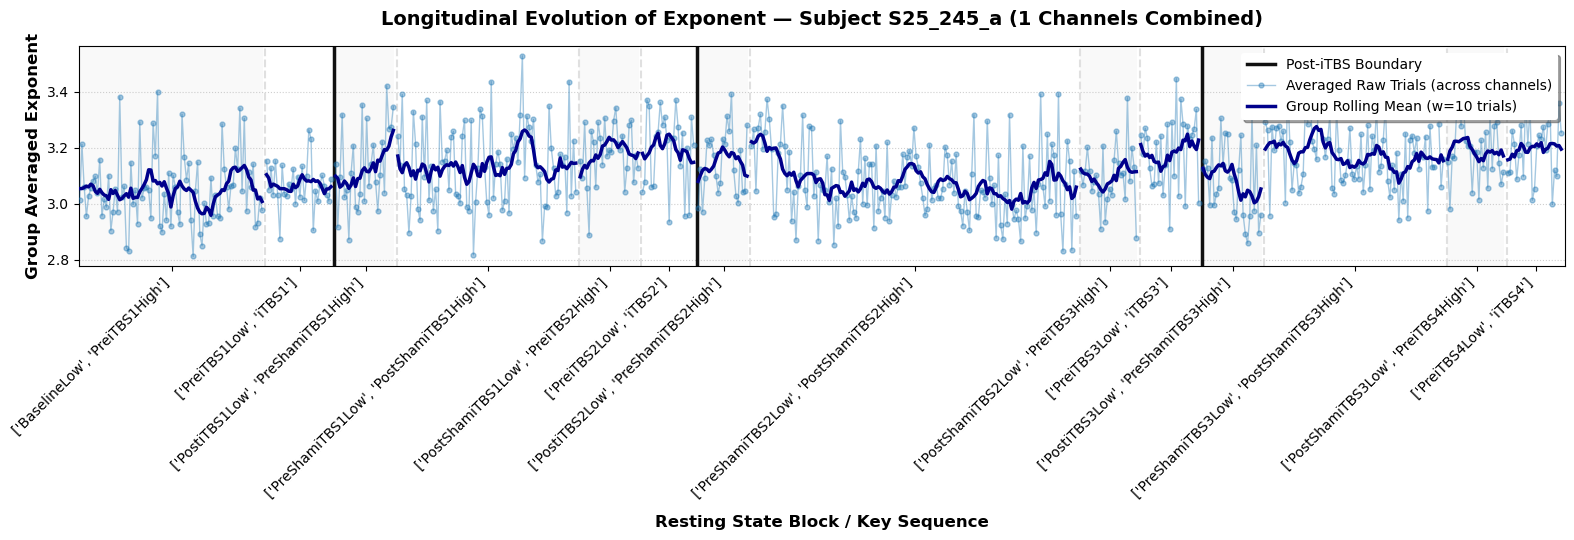

In [9]:
s = 'S25_245_a'
band_ = 'theta'

# To plot the aperiodic 1/f Exponent (param_idx=1) for subject 'S25_245':
plot_group_parameter_longitudinally(plot_subset_top, subject_id=s, data_dir='../outputs/fooof_extendedrange/',
                                    param_idx=1, param_name="Exponent", window_size=10, band=band_,
                                   fname=None)

### Plot group-level statistics: Exponent, Offset

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_48730/145812353.py:466: RuntimeWarning: Mean of empty slice
  group_trial_avg = np.nanmean(z_scored_matrix, axis=0)


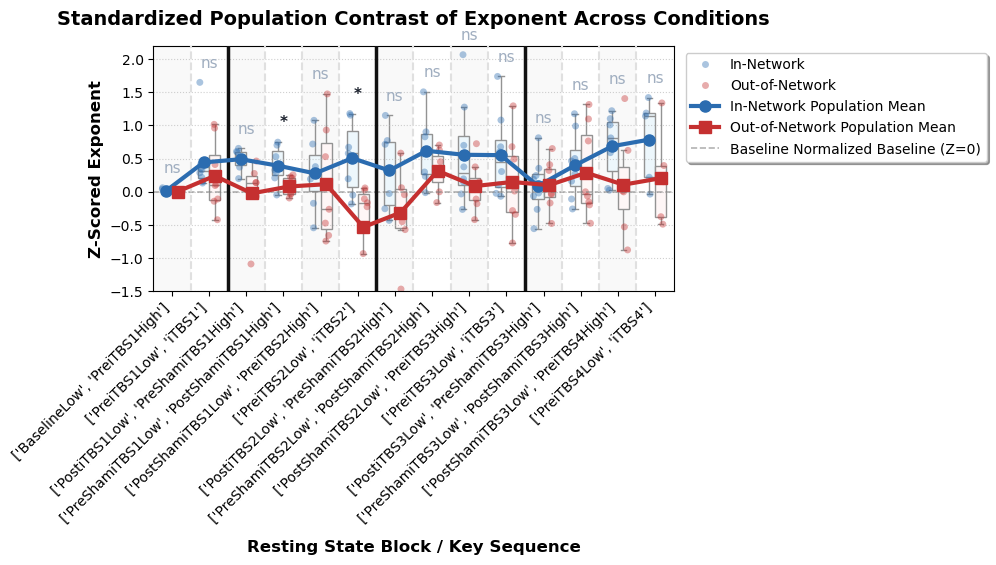

,Subject,Block,Value,Group
0,S25_245_a,"['BaselineLow', 'PreiTBS1High']",-4.130565e-15,In-Network
1,S25_245_a,"['PreiTBS1Low', 'iTBS1']",1.548319e-01,In-Network
2,S25_245_a,"['PostiTBS1Low', 'PreShamiTBS1High']",6.552497e-01,In-Network
3,S25_245_a,"['PreShamiTBS1Low', 'PostShamiTBS1High']",7.039813e-01,In-Network
4,S25_245_a,"['PostShamiTBS1Low', 'PreiTBS2High']",1.077854e+00,In-Network
...,...,...,...,...
197,S25_248_a,"['PreiTBS3Low', 'iTBS3']",6.805094e-01,Out-of-Network
198,S25_248_a,"['PostiTBS3Low', 'PreShamiTBS3High']",4.094394e-01,Out-of-Network
199,S25_248_a,"['PreShamiTBS3Low', 'PostShamiTBS3High']",7.667600e-01,Out-of-Network
200,S25_248_a,"['PostShamiTBS3Low', 'PreiTBS4High']",6.251418e-01,Out-of-Network


In [15]:
resting_state_blocks_r01_str = [str(i) for i in resting_state_blocks_r01]

plot_block_distribution_population_comparison(plot_subset_top, plot_subset_bottom, label1='In-Network', label2='Out-of-Network',
                                              param_idx=1, param_name="Exponent", data_dir='../outputs/fooof_extendedrange/', band='theta', ylim_=(-1.5, 2.2),
                                              block_order=None, fname=None)

--- T-Test Results for Exponent ---
[In-Network | iTBS1] t-stat:  0.0912, p-value: 9.3084e-01
[In-Network | iTBS2] t-stat:  1.0162, p-value: 3.5615e-01
[In-Network | iTBS3] t-stat:  2.4858, p-value: 4.7433e-02
[Out-of_Network | iTBS1] t-stat:  0.9477, p-value: 3.8679e-01
[Out-of_Network | iTBS2] t-stat: -0.8880, p-value: 4.1523e-01
[Out-of_Network | iTBS3] t-stat:  0.0185, p-value: 9.8586e-01


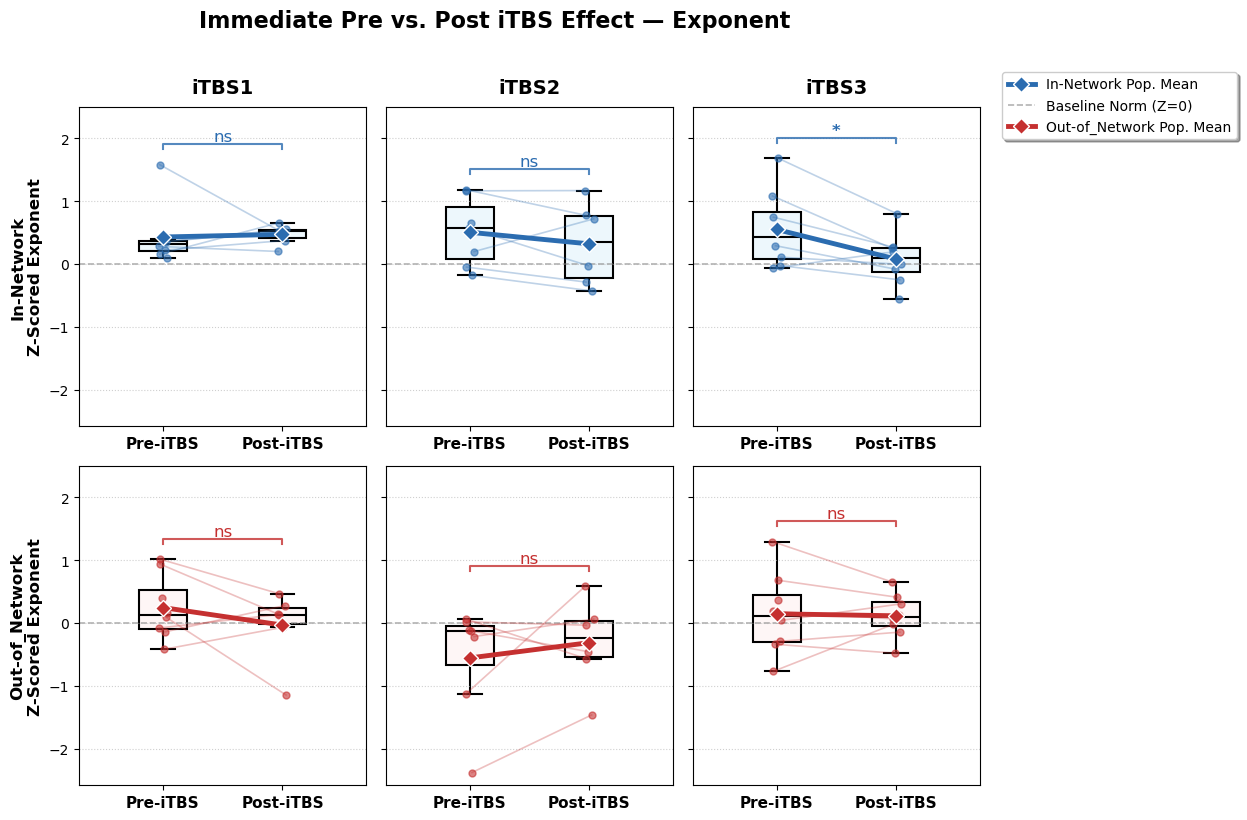

In [16]:
# Create a combined in-network and out-of-network DataFrame and plot results
df_combined = plot_itbs_pre_post_comparison(plot_subset_top, plot_subset_bottom, param_idx=1, label1='In-Network', 
                                            label2='Out-of_Network', param_name='Exponent', data_dir='../outputs/fooof_extendedrange/', 
                                            band='theta', ylim_=None, fname=None, figsize_=(10, 8))

**Mixed effects model to test for significance between in-network and out-of-network**

In [17]:
from patsy.contrasts import Sum
import statsmodels.api as sm
import statsmodels.formula.api as smf

use_block_avg = False

df_copy = df_combined.copy()
df_copy = df_copy[(df_copy['Group'].str.contains('')) & 
                  (df_copy['Session'].str.contains('')) ]

# 1. Define the identifier columns
id_cols = ['Subject', 'Channel', 'Session', 'Group']

# 2. Pivot 'Timepoint' into separate columns for 'Value'
df_wide = df_copy.pivot(
    index=id_cols, 
    columns='Timepoint', 
    values='Value'
).reset_index()

# 3. Rename columns to match your requested names
df_wide = df_wide.rename(columns={
    'pre': 'Pre_Value',
    'post': 'Post_Value'
})

# 4. Compute the Difference (Post minus Pre)
df_wide['Difference'] = df_wide['Post_Value'] - df_wide['Pre_Value']

# 5. Reorder columns cleanly
cols_order = id_cols + ['Pre_Value', 'Post_Value', 'Difference']
df_diff = df_wide[cols_order]

# mixedlm cannot handle missing values in the fixed or random effects columns
df_clean = df_diff.dropna(subset=['Difference', 'Subject', 'Channel', 'Session'])
df_clean['subject_channel'] = df_clean['Subject'].astype(str) + "_" + df_clean['Channel'].astype(str)

# If wanting to average across sessions/blocks firsts
df_block_avg = df_clean.groupby(['Subject', 'Channel', 'Group'])['Difference'].mean().reset_index()

if use_block_avg:
    
# Define model structure
    formula = "Difference ~ 1 + C(Group)"
    
    model = smf.mixedlm(
        formula=formula, 
        data=df_block_avg, 
        groups=df_block_avg["Subject"], 
    )
    
    # Fit the Model 
    # remethod='REML' (Restricted Maximum Likelihood) is standard for mixed models to yield unbiased variance estimates
    result = model.fit(method=None)

else:
    formula = "Difference ~ C(Session, Sum) + C(Group)"
    
    model = smf.mixedlm(
        formula=formula, 
        data=df_clean, 
        groups=df_clean["Subject"], 
    )
    
    # Fit the Model 
    # remethod='REML' (Restricted Maximum Likelihood) is standard for mixed models to yield unbiased variance estimates
    result = model.fit(method='powell')
    
# Print Summary 
print(result.summary())


                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     Difference
No. Observations:      248         Method:                 REML      
No. Groups:            9           Scale:                  0.4721    
Min. group size:       2           Log-Likelihood:         -269.1413 
Max. group size:       92          Converged:              Yes       
Mean group size:       27.6                                          
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  -0.290    0.132 -2.193 0.028 -0.549 -0.031
C(Session, Sum)[S.iTBS1]   -0.308    0.076 -4.039 0.000 -0.457 -0.158
C(Session, Sum)[S.iTBS2]    0.177    0.079  2.236 0.025  0.022  0.331
C(Group)[T.Out-of_Network]  0.267    0.087  3.064 0.002  0.096  0.438
Group Var                   0.080   

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_48730/2102920277.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['subject_channel'] = df_clean['Subject'].astype(str) + "_" + df_clean['Channel'].astype(str)


### Analyze correlation between CCEP-related measures and resting-state measures
Note: First need to re-construct DataFrames with more permissive z-score threshold of 3 to capture high/low variability. 

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_48730/469109876.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.assign(abs_val=df[col_name].abs()).groupby('subject', group_keys=False).apply(


--- T-Test Results for Exponent ---
[In-Network | iTBS1] t-stat:  0.9552, p-value: 3.7130e-01
[In-Network | iTBS2] t-stat: -1.2998, p-value: 2.4138e-01
[In-Network | iTBS3] t-stat:  0.6127, p-value: 5.5707e-01
[Out-of_Network | iTBS1] t-stat:  1.1959, p-value: 2.7065e-01
[Out-of_Network | iTBS2] t-stat: -0.7600, p-value: 4.7603e-01
[Out-of_Network | iTBS3] t-stat:  0.3168, p-value: 7.5948e-01


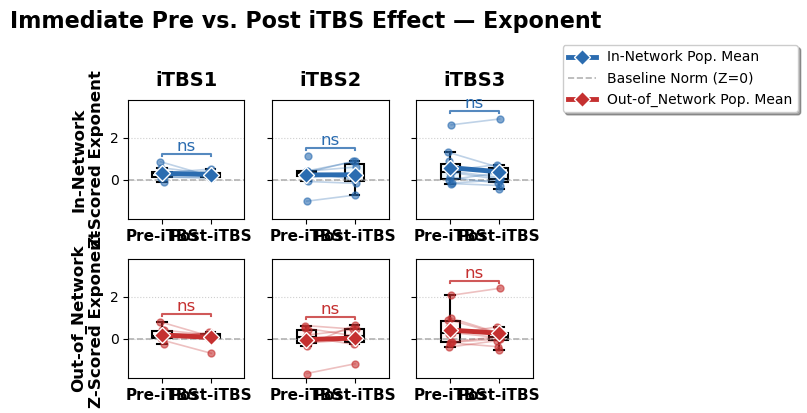

In [39]:
# In-network
plot_subset_top = df_joint[ 
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains(r01_subject_strings)) & 
                        (df_joint['is_bad'] == False) &
                        (df_joint['block']=='iTBS1') & 
                        (df_joint['is_lead'] == False) &
                        (df_joint['baseline_ptp']>3)
                            ]
# Out of Network
plot_subset_bottom = df_joint[ 
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains(r01_subject_strings)) & 
                        (df_joint['is_bad'] == False) &
                        (df_joint['block']=='iTBS1') & 
                        (df_joint['is_lead'] == False) 
                            ]
sub_ns = {k: v for d in [{s: len(plot_subset_top[plot_subset_top['subject']==s])} for s in plot_subset_top['subject'].unique()] for k, v in d.items()}
plot_subset_bottom = get_smallest_channels(plot_subset_bottom[plot_subset_bottom['subject'].str.contains("|".join(map(str, sub_ns.keys())))], 'baseline_ptp', N=sub_ns)

# Create a combined in-network and out-of-network DataFrame and plot results
df_combined = plot_itbs_pre_post_comparison(plot_subset_top, plot_subset_bottom, param_idx=1, label1='In-Network', 
                                            label2='Out-of_Network', param_name='Exponent', data_dir='../outputs/fooof_extendedrange/', 
                                            band='theta', ylim_=None, fname=None, figsize_=(5, 4))

**1. Reorganize data into a new DataFrame for easier mixed effects analysis**

In [40]:
# win_centers is defined in prior analyses, corresponds to timepoints in 't_stats' column of df_electrodes structure
win_centers = win_centers = np.arange(-0.9, 2.16, 0.05)

# Zero in on the previously-determined significant time window for the HFA effect
sig_timepoints = np.where((win_centers>=0.7) & (win_centers<=0.85))

# Data holder for records
records = []

# Params
for tbs in ['iTBS1', 'iTBS2', 'iTBS3']:
    subselect = df_combined[(df_combined['Group']=='In-Network') & (df_combined['Session']==tbs) & (df_combined['Timepoint']=='pre')]
    
    for idx in range(len(subselect)):
        sub = subselect.iloc[idx]['Subject']
        chan = subselect.iloc[idx]['Channel']
        
        post_row = df_combined[(df_combined['Group']=='In-Network') &
            (df_combined['Session']==tbs) &
            (df_combined['Timepoint']=='post') & 
            (df_combined['Subject']==sub) & 
            (df_combined['Channel']==chan)]

        if len(post_row) == 0:
            print('Post data not found for ' + sub + ', ' + chan)
            records.append({
                'Session': tbs,
                'Subject': sub,
                'Channel': chan,
                'exp_diff': np.nan,
                'pow_tstat': np.nan,
                'ptp_stat': np.nan
            })
            continue

        if len(post_row) > 1:
            print('Some kind of error here!')

        # Compute metrics
        diff = post_row.iloc[0]['Value'] - subselect.iloc[idx]['Value']
        pow_tstat = np.nanmean(post_row.iloc[0]['t_stats'][sig_timepoints])
        ptp_stat = post_row.iloc[0]['baseline_ptp']

        # Append structured dictionary to records
        records.append({
            'Session': tbs,
            'Subject': sub,
            'Channel': chan,
            'exp_diff': diff,
            'pow_tstat': pow_tstat,
            'ptp_stat': ptp_stat
        })

# Create aggregated DataFrame
df_aggregated = pd.DataFrame(records)

Post data not found for S23_211_a, LHPC10-LHPC11
Post data not found for S23_211_a, LATH1-LATH2
Post data not found for S23_211_a, LATH2-LATH3
Post data not found for S23_211_a, LATH3-LATH4
Post data not found for S23_211_a, LATH7-LATH8
Post data not found for S23_211_a, LPTH1-LPTH2
Post data not found for S23_211_a, LPTH3-LPTH4
Post data not found for S23_211_a, LPTH4-LPTH5
Post data not found for S23_211_a, LPTH11-LPTH12
Post data not found for S23_211_a, LPTH12-LPTH13
Post data not found for S23_211_a, RHPC4-RHPC5
Post data not found for S23_211_a, RHPC5-RHPC6
Post data not found for S23_211_a, RHPC6-RHPC7
Post data not found for S23_211_a, RHPC7-RHPC8
Post data not found for S23_211_a, RHPC8-RHPC9
Post data not found for S23_211_a, RHPC9-RHPC10
Post data not found for S23_211_a, RINA2-RINA3
Post data not found for S23_211_a, RINB2-RINB3
Post data not found for S23_211_a, RINB3-RINB4
Post data not found for S23_211_a, RINB5-RINB6
Post data not found for S23_211_a, RINB8-RINB9
Post d

**2. Fit the model and plot results**

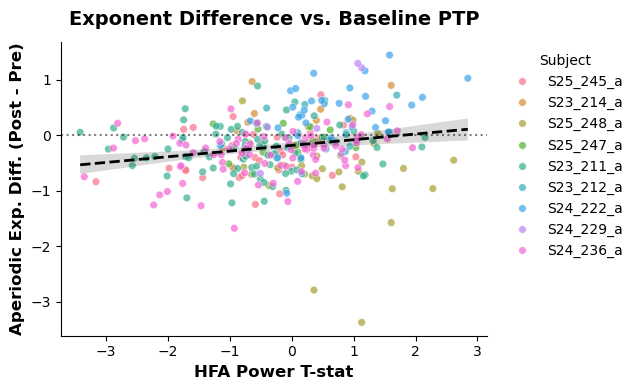

             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    exp_diff 
No. Observations:    309        Method:                REML     
No. Groups:          9          Scale:                 0.2072   
Min. group size:     6          Log-Likelihood:        -210.2718
Max. group size:     85         Converged:             Yes      
Mean group size:     34.3                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.103    0.097 -1.070 0.285 -0.293  0.086
pow_tstat              0.152    0.064  2.366 0.018  0.026  0.278
Group Var              0.073    0.095                           
Group x pow_tstat Cov  0.042    0.054                           
pow_tstat Var          0.026    0.042                           



In [41]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a unique channel identifier per subject for nesting
df_aggregated['subject_channel'] = df_aggregated['Subject'].astype(str) + "_" + df_aggregated['Channel'].astype(str)

# Clean missing values prior to modeling
df_clean = df_aggregated.dropna(subset=['exp_diff', 'ptp_stat', 'Session', 'Subject', 'subject_channel', 'pow_tstat']).copy()
df_clean['ptp_stat'] = np.log10(df_clean['ptp_stat'])
df_clean = df_clean[(df_clean['Session'].str.contains('iTBS3')) &
                    df_clean['Subject'].str.contains('')]

# ==========================================
# 1. VISUALIZATION: Scatter & Trendline
# ==========================================
fig, ax = plt.subplots(figsize=(6.5, 4))

# Scatter plot grouped by subject
sns.scatterplot(
    data=df_clean, 
    x='pow_tstat', 
    y='exp_diff', 
    hue='Subject', 
    palette='husl', 
    alpha=0.7, 
    s=30, 
    ax=ax
)

# Global linear trendline
sns.regplot(
    data=df_clean, 
    x='pow_tstat', 
    y='exp_diff', 
    ax=ax, 
    scatter=False, 
    color='black', 
    line_kws={'linestyle': '--', 'linewidth': 2}
)

ax.set_xlabel('HFA Power T-stat', fontsize=12, fontweight='bold')
ax.set_ylabel('Aperiodic Exp. Diff. (Post - Pre)', fontsize=12, fontweight='bold')
ax.set_title('Exponent Difference vs. Baseline PTP', fontsize=14, fontweight='bold', pad=12)
ax.axhline(0, color='black', linestyle=':', alpha=0.5)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title='Subject', frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
#plt.savefig('./figs/resting_correlation_hfa.pdf')
plt.show()

# ==========================================
# 2. LINEAR MIXED-EFFECTS MODEL (LMM)
# ==========================================
# Fixed effects: ptp_stat + C(Session)
# Random effects: 
#   - Grouped by Subject (groups=df_clean["Subject"])
#   - Random slope for ptp_stat/pow_tstat per Subject (e.g. re_formula="~ptp_stat")

formula = "exp_diff ~ pow_tstat"

lme_model = smf.mixedlm(
    formula=formula,
    data=df_clean,
    groups=df_clean["Subject"],
    re_formula="~pow_tstat",                                     # Random slope per subject
)

lme_result = lme_model.fit(method='powell')
print(lme_result.summary())